# Water Body Segmentation â€” End-to-End Demo

Demonstrates the complete pipeline: data loading â†’ model inference â†’ evaluation â†’ visuals.

> Run `python -m src.training.train` first to generate `best_model.pth`

In [1]:
import sys, os
sys.path.insert(0, '..')  # project root

import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mlflow

from src.ingestion.dataset import get_loaders
from src.training.model import get_model
from src.training.utils import get_metrics

DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
IMG_DIR  = '../data/Images'
MASK_DIR = '../data/Masks'
WEIGHTS  = '../best_model.pth'
print(f'Device: {DEVICE}')

C:\Users\KRISHNA GUPTA\AppData\Local\Programs\Python\Python311\Lib\site-packages\pydantic\_internal\_fields.py:132: UserWarning: Field "model_name" in PromptModelConfig has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(


Device: cuda


## 1. Data Pipeline

In [2]:
train_loader, val_loader = get_loaders(IMG_DIR, MASK_DIR, batch_size=8)
print(f'Train samples : {len(train_loader.dataset)}')
print(f'Val   samples : {len(val_loader.dataset)}')
imgs, masks = next(iter(train_loader))
print(f'Batch â€” images: {imgs.shape}, masks: {masks.shape}')
print(f'Image range   : [{imgs.min():.2f}, {imgs.max():.2f}]')
print(f'Mask unique   : {masks.unique().tolist()}')

Train samples : 2273
Val   samples : 568


Batch â€” images: torch.Size([8, 3, 256, 256]), masks: torch.Size([8, 1, 256, 256])
Image range   : [-2.12, 2.43]
Mask unique   : [0.0, 1.0]


## 2. Load Model

In [3]:
model = get_model().to(DEVICE)
model.load_state_dict(torch.load(WEIGHTS, map_location=DEVICE))
model.eval()
print('Model loaded.')

Unet-ResNet34: 24.44M params


Model loaded.


## 3. Validation Metrics

In [4]:
totals = {'iou': 0, 'accuracy': 0, 'precision': 0, 'recall': 0}
with torch.no_grad():
    for imgs, masks in val_loader:
        preds = model(imgs.to(DEVICE))
        m = get_metrics(preds, masks.to(DEVICE).float())
        for k in totals: totals[k] += m[k]
n = len(val_loader)
print('=== Validation Results ===')
for k, v in totals.items():
    print(f'{k.capitalize():<12}: {v/n:.4f}')

=== Validation Results ===
Iou         : 0.7144
Accuracy    : 0.8901
Precision   : 0.8608
Recall      : 0.8061


## 4. Predictions vs Ground Truth

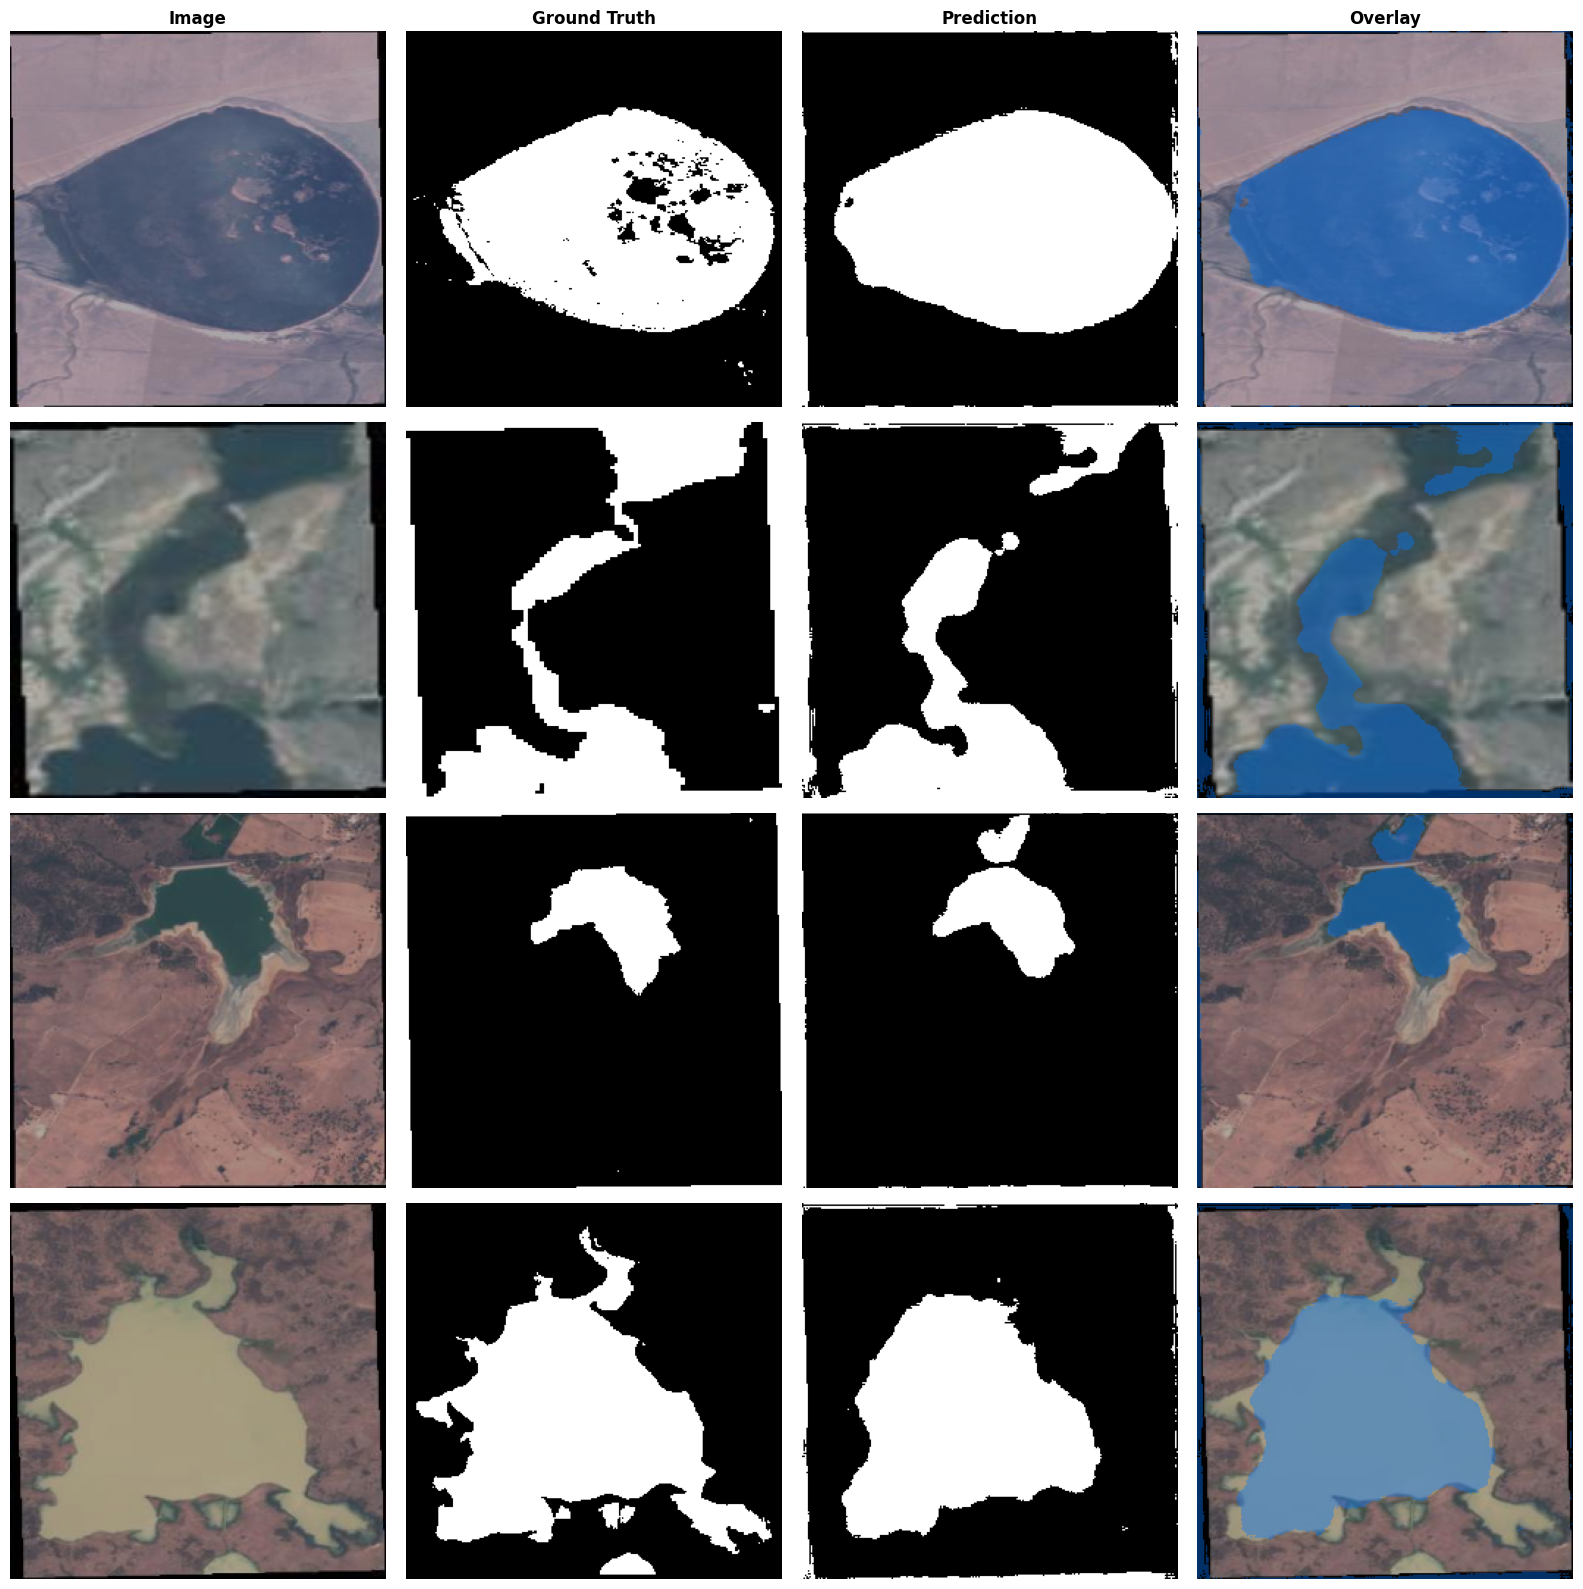

In [5]:
def denorm(t):
    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    return (t.cpu()*std+mean).clamp(0,1).permute(1,2,0).numpy()

imgs, masks = next(iter(val_loader))
with torch.no_grad():
    preds = torch.sigmoid(model(imgs.to(DEVICE))).cpu()

N = 4
fig, axes = plt.subplots(N, 4, figsize=(16, N*4))
for ax, col in zip(axes[0], ['Image','Ground Truth','Prediction','Overlay']):
    ax.set_title(col, fontsize=12, fontweight='bold')

for i in range(N):
    img_np  = denorm(imgs[i])
    gt_np   = masks[i].squeeze().numpy()
    pred_np = (preds[i].squeeze().numpy() > 0.5).astype(np.float32)
    overlay = (img_np*255).astype(np.uint8).copy()
    overlay[pred_np==1] = [0,120,255]
    blended = cv2.addWeighted((img_np*255).astype(np.uint8), 0.6, overlay, 0.4, 0)
    m = get_metrics(preds[i:i+1], masks[i:i+1].float())
    axes[i,0].imshow(img_np);              axes[i,0].axis('off')
    axes[i,1].imshow(gt_np, cmap='gray');  axes[i,1].axis('off')
    axes[i,2].imshow(pred_np,cmap='gray'); axes[i,2].set_xlabel(f"IOU={m['iou']:.3f}"); axes[i,2].axis('off')
    axes[i,3].imshow(blended);             axes[i,3].axis('off')

plt.tight_layout()
plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Failure Cases

Mean IOU : 0.3455
IOU < 0.5: 456 images
IOU > 0.9: 36 images


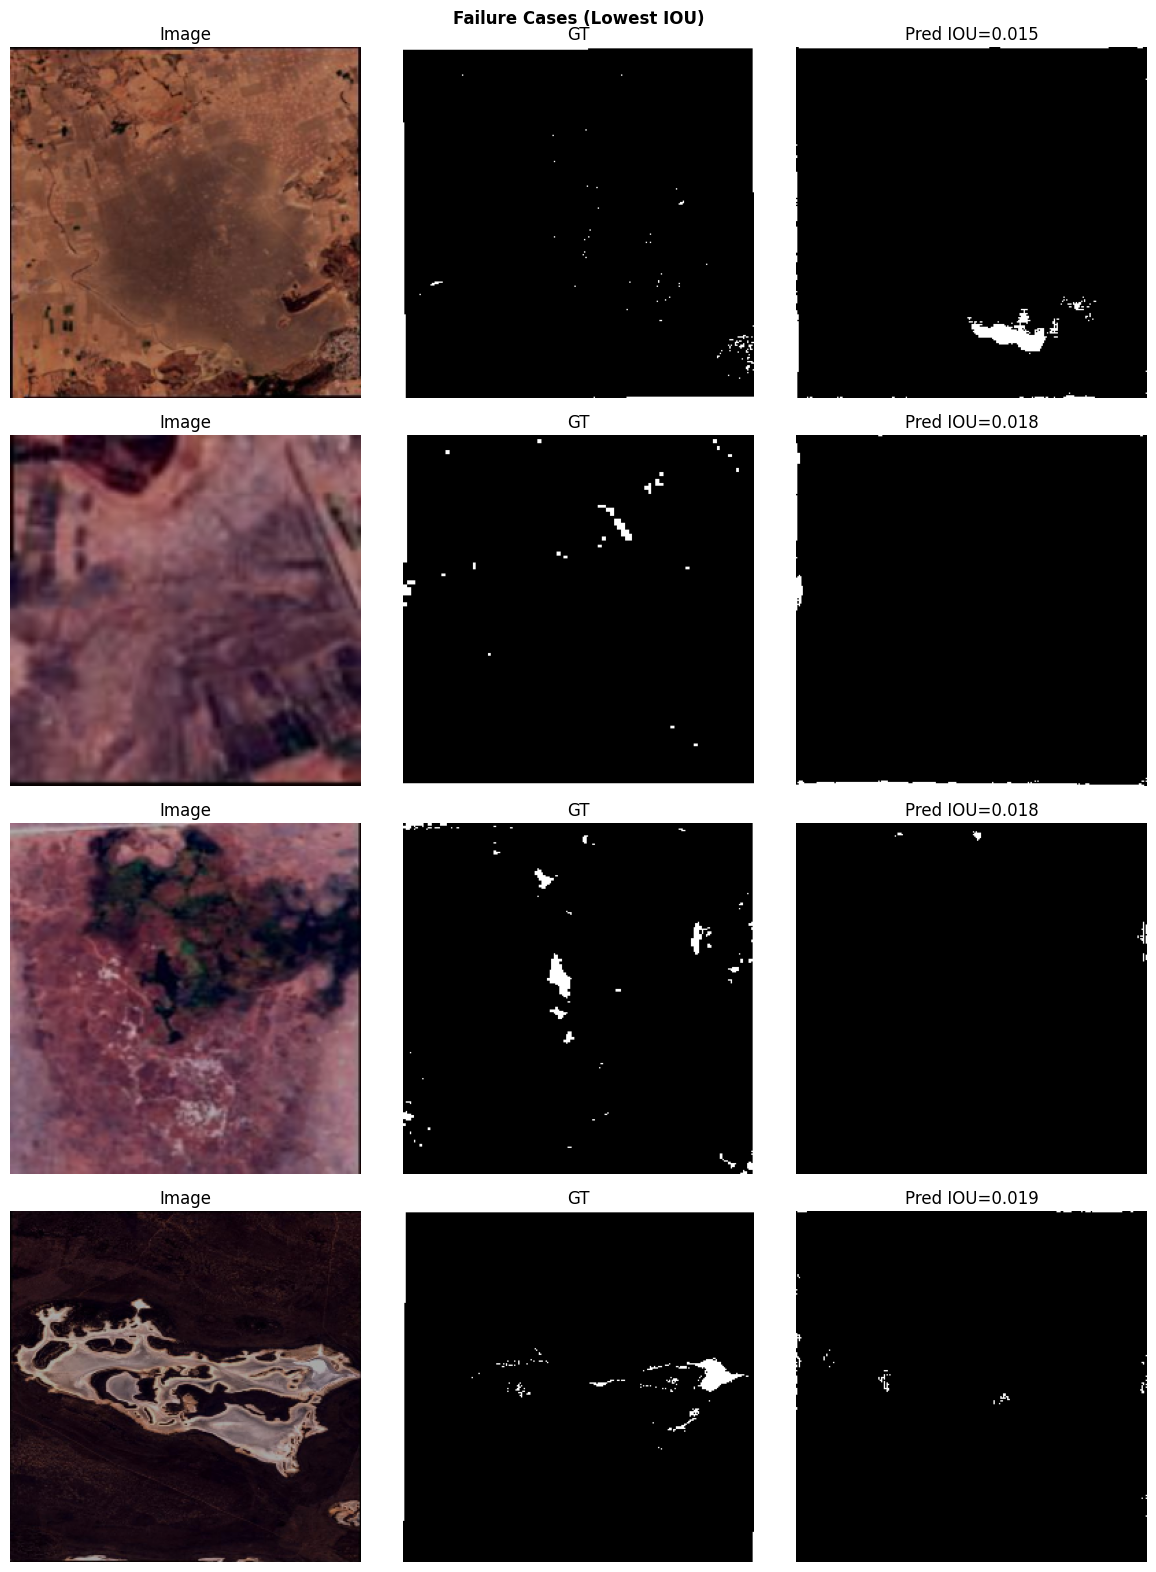

In [6]:
sample_ious, all_imgs, all_masks, all_preds = [], [], [], []
with torch.no_grad():
    for imgs, masks in val_loader:
        preds = torch.sigmoid(model(imgs.to(DEVICE))).cpu()
        for i in range(len(imgs)):
            m = get_metrics(preds[i:i+1], masks[i:i+1].float())
            sample_ious.append(m['iou'])
            all_imgs.append(imgs[i]); all_masks.append(masks[i]); all_preds.append(preds[i])

sample_ious = np.array(sample_ious)
print(f'Mean IOU : {sample_ious.mean():.4f}')
print(f'IOU < 0.5: {(sample_ious < 0.5).sum()} images')
print(f'IOU > 0.9: {(sample_ious > 0.9).sum()} images')

worst = np.argsort(sample_ious)[:4]
fig, axes = plt.subplots(4, 3, figsize=(12, 16))
fig.suptitle('Failure Cases (Lowest IOU)', fontweight='bold')
for row, idx in enumerate(worst):
    axes[row,0].imshow(denorm(all_imgs[idx]));                         axes[row,0].set_title('Image'); axes[row,0].axis('off')
    axes[row,1].imshow(all_masks[idx].squeeze(), cmap='gray');         axes[row,1].set_title('GT');    axes[row,1].axis('off')
    axes[row,2].imshow((all_preds[idx].squeeze()>0.5), cmap='gray');   axes[row,2].set_title(f'Pred IOU={sample_ious[idx]:.3f}'); axes[row,2].axis('off')
plt.tight_layout()
plt.savefig('failure_cases.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. MLflow Run Comparison

In [7]:
client = mlflow.tracking.MlflowClient()
rows = []
for exp in client.search_experiments():
    for run in client.search_runs(exp.experiment_id, order_by=['metrics.val_iou DESC']):
        p, m = run.data.params, run.data.metrics
        rows.append({
            'Run':       run.info.run_name,
            'LR':        p.get('lr','-'),
            'Batch':     p.get('batch_size','-'),
            'IOU':       round(m.get('val_iou',0),4),
            'Accuracy':  round(m.get('val_accuracy',0),4),
            'Precision': round(m.get('val_precision',0),4),
            'Recall':    round(m.get('val_recall',0),4),
            'Val Loss':  round(m.get('val_loss',0),4),
        })
if rows:
    df = pd.DataFrame(rows).sort_values('IOU', ascending=False)
    display(df)
else:
    print('No MLflow runs found. Run src/training/train.py first.')

No MLflow runs found. Run src/training/train.py first.


## 7. Run Inference on New Image

Input: ../data/Images\water_body_1.jpg


Unet-ResNet34: 24.44M params


2026-05-21 00:56:29,631 [INFO] water_body_1.jpg (2009x2007) -> 81 tiles


2026-05-21 00:56:31,406 [INFO] Done in 2.956s | backend=pytorch


Inference time: 2.987s


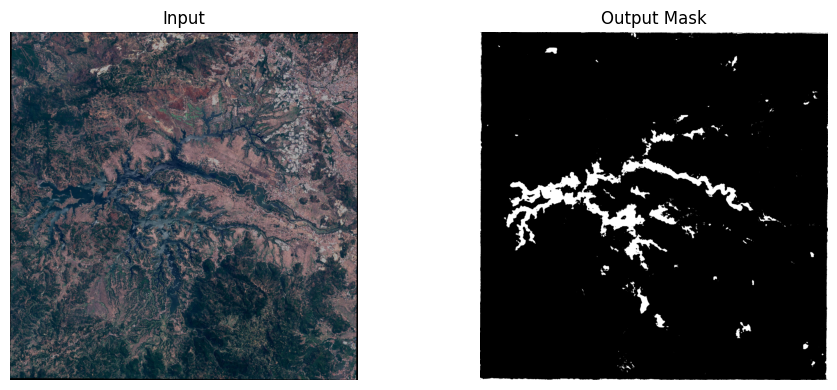

In [8]:
import time
from src.inference.inference import predict

sample_img = os.path.join(IMG_DIR, sorted(os.listdir(IMG_DIR))[0])
print(f'Input: {sample_img}')

t0   = time.time()
mask = predict(sample_img, out_path='demo_output.png', backend='pytorch', weights_path=WEIGHTS)
print(f'Inference time: {time.time()-t0:.3f}s')

orig = cv2.cvtColor(cv2.imread(sample_img), cv2.COLOR_BGR2RGB)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(orig);             axes[0].set_title('Input');  axes[0].axis('off')
axes[1].imshow(mask, cmap='gray');axes[1].set_title('Output Mask'); axes[1].axis('off')
plt.tight_layout()
plt.show()

## Summary

| Component | Implementation | Notes |
|-----------|---------------|-------|
| Data pipeline | `src/ingestion/dataset.py` | 256Ã—256 resize, augmentation, JPEG artifact fix (>200) |
| Model | U-Net + ResNet34 | 21M params, ImageNet pretrained |
| Loss | BCE + Dice (50/50) | Handles 32/68 class imbalance |
| Tracking | MLflow | IOU, Accuracy, Precision, Recall, Loss per epoch |
| Inference | ONNX + tiling | ~2x CPU speedup vs PyTorch |
| Deployment | Docker | `docker build -t water-seg .` |

### Known Limitations
- Training uses resize not tiling â€” patching caused class collapse (IOU=0.40) as Kaggle images are pre-cropped small JPEGs. Tiling is preserved for inference on true large rasters.
- RGB only â€” true Sentinel-2 NIR band would improve water boundary detection.
- JPEG mask compression introduces boundary noise despite threshold fix.

### Suggested Next Steps
1. **EfficientNet-B4 encoder** â€” larger capacity for +2â€“3% IOU at acceptable GPU cost
2. **Test-time augmentation (TTA)** â€” average flipped predictions at inference
3. **Morphological closing** â€” fill small holes in output masks
4. **Multispectral input** â€” add NIR band from raw Sentinel-2 if available
5. **CRF post-processing** â€” sharpen water/non-water boundaries